In [85]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from thesis.common.logger import setup_logger
from thesis.eta.experiment import convert_results_to_dataframe, initialize_experiment, load_experiment_results

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

experiment_name = "comparison"
_, logs_dir, _, _ = initialize_experiment(experiment_name)
logger = setup_logger(experiment_name, logs_dir)

2025-07-08 20:51:49 - comparison - INFO - Starting experiment comparison


In [87]:
all_results = load_experiment_results()
df_results = convert_results_to_dataframe(all_results)

2025-07-08 20:51:49 - thesis.eta.experiment - INFO - Loaded 25 experiment results
2025-07-08 20:51:49 - thesis.eta.experiment - INFO - Converted 400 records to DataFrame


## Compare Experiments to Baseline

Let's compare all experiments to the baseline performance using MAPE and MAE as our primary metrics.


In [88]:
# Use all models (including linear regression as baseline)
df_all = df_results.copy()

# Calculate relative improvements compared to baseline
baseline_results = df_all[df_all["experiment"] == "baseline"].set_index(["scenario", "model"])

# For each experiment, calculate the improvement over baseline
for experiment in df_all["experiment"].unique():
    if experiment != "baseline":
        exp_results = df_all[df_all["experiment"] == experiment].set_index(["scenario", "model"])

        # Calculate relative change in MAPE (lower is better, so negative is improvement)
        df_all.loc[df_all["experiment"] == experiment, "mape_improvement"] = df_all[
            df_all["experiment"] == experiment
        ].apply(
            lambda row: (baseline_results.loc[(row["scenario"], row["model"]), "mape"] - row["mape"])
            / baseline_results.loc[(row["scenario"], row["model"]), "mape"]
            * 100,
            axis=1,
        )

        # Calculate relative change in MAE (lower is better, so negative is improvement)
        df_all.loc[df_all["experiment"] == experiment, "mae_improvement"] = df_all[
            df_all["experiment"] == experiment
        ].apply(
            lambda row: (baseline_results.loc[(row["scenario"], row["model"]), "mae"] - row["mae"])
            / baseline_results.loc[(row["scenario"], row["model"]), "mae"]
            * 100,
            axis=1,
        )

# Display improvements
improvement_cols = ["experiment", "scenario", "model", "mape", "mae", "mape_improvement", "mae_improvement"]
df_improvements = df_all[df_all["experiment"] != "baseline"][improvement_cols].round(4)
df_improvements.sort_values(["mape_improvement"], ascending=False).head(10)

,experiment,scenario,model,mape,mae,mape_improvement,mae_improvement
177,baseline_new_networks,closure,xgboost,0.1342,30.1765,40.9497,47.1678
179,baseline_new_networks,closure,catboost,0.1341,30.1591,38.8412,45.5858
178,baseline_new_networks,closure,lightgbm,0.1380,30.8203,37.7997,44.7301
149,baseline_newest_event,closure,xgboost,0.1481,34.4006,34.8566,39.7723
213,baseline_omonoia_syntagma,closure,xgboost,0.1486,40.6368,34.6467,28.8542
176,baseline_new_networks,closure,lr,0.1539,34.3556,34.0784,40.6765
151,baseline_newest_event,closure,catboost,0.1475,34.2080,32.7257,38.2806
150,baseline_newest_event,closure,lightgbm,0.1515,34.8525,31.7191,37.4992
215,baseline_omonoia_syntagma,closure,catboost,0.1502,40.8718,31.5188,26.2575
133,baseline_newest,closure,xgboost,0.1557,37.1959,31.4950,34.8785


## Average Performance by Experiment


In [89]:
# Calculate average metrics across all scenarios and models for each experiment
avg_by_experiment = df_all.groupby("experiment")[["mape", "mae", "rmse"]].mean().round(4)

# Add improvement columns for non-baseline experiments
for experiment in avg_by_experiment.index:
    if experiment != "baseline":
        improvement_data = df_all[df_all["experiment"] == experiment][["mape_improvement", "mae_improvement"]].mean()
        avg_by_experiment.loc[experiment, "avg_mape_improvement"] = improvement_data["mape_improvement"]
        avg_by_experiment.loc[experiment, "avg_mae_improvement"] = improvement_data["mae_improvement"]

# Sort by MAPE (lower is better)
avg_by_experiment = avg_by_experiment.sort_values("mape")
print("Average Performance by Experiment (All Models Including Linear Regression):")
print("=" * 80)
avg_by_experiment


Average Performance by Experiment (All Models Including Linear Regression):


,mape,mae,rmse,avg_mape_improvement,avg_mae_improvement
experiment,,,,,
baseline_newest_event,0.1472,35.5233,71.2920,17.484324,21.647513
baseline_omonoia_syntagma,0.1517,41.1503,100.1993,15.084565,10.746071
baseline_newest_plus,0.1540,38.3347,84.1684,14.060831,16.270762
baseline_new_networks,0.1574,49.1858,128.1952,10.118219,3.236379
baseline_0.38,0.1587,43.8334,87.1215,4.666544,9.987151
baseline_final_way,0.1602,40.5204,84.5872,11.078917,12.550638
baseline_wtf,0.1608,35.5813,63.1564,3.709685,25.658531
baseline_newest,0.1621,51.5978,135.2089,7.982051,-1.514032
quantile_normal_transform_target_new,0.1621,48.1329,106.0534,8.856437,5.238534


## Performance by Model


In [90]:
# Average performance by model across all experiments
avg_by_model = df_all.groupby("model")[["mape", "mae", "rmse"]].mean().round(4)
avg_by_model = avg_by_model.sort_values("mape")

print("Average Performance by Model (Across All Experiments):")
print("=" * 60)
avg_by_model

Average Performance by Model (Across All Experiments):


,mape,mae,rmse
model,,,
catboost,0.1652,48.5588,113.8705
xgboost,0.1672,48.9897,114.1998
lightgbm,0.1678,48.9868,114.2808
lr,0.1892,53.9476,120.9928


## Performance by Scenario


In [91]:
# Performance by scenario
avg_by_scenario = df_all.groupby("scenario")[["mape", "mae", "rmse"]].mean().round(4)
avg_by_scenario = avg_by_scenario.sort_values("mape")

print("Average Performance by Scenario (All Models):")
print("=" * 60)
avg_by_scenario


Average Performance by Scenario (All Models):


,mape,mae,rmse
scenario,,,
base,0.1481,34.5290,70.8522
base-closure,0.1657,52.6923,134.1410
base-rain,0.1682,57.4516,136.9592
rain,0.1736,53.0581,127.9142
closure,0.2125,56.9756,121.1510


## Overall Rankings

Let's create a comprehensive ranking of all experiment-model-scenario combinations.


In [92]:
# Create a ranking based on MAPE (lower is better)
df_ranking = df_all[["experiment", "scenario", "model", "mape", "mae", "rmse"]].copy()
df_ranking["rank_by_mape"] = df_ranking["mape"].rank()
df_ranking["rank_by_mae"] = df_ranking["mae"].rank()  # Lower MAE is better

# Sort by MAPE rank
df_ranking = df_ranking.sort_values("rank_by_mape")

# Show top 15 best performing combinations
print("Top 15 Best Performing Combinations (by MAPE):")
print("=" * 100)
df_ranking.head(15)


Top 15 Best Performing Combinations (by MAPE):


,experiment,scenario,model,mape,mae,rmse,rank_by_mape,rank_by_mae
351,quantile_normal_transform_target_new,base,catboost,0.128728,28.847123,52.494836,1.0,1.0
349,quantile_normal_transform_target_new,base,xgboost,0.129376,28.877605,52.178009,2.0,2.0
350,quantile_normal_transform_target_new,base,lightgbm,0.132335,29.537553,53.673267,3.0,3.0
179,baseline_new_networks,closure,catboost,0.134104,30.159105,55.218963,4.0,4.0
177,baseline_new_networks,closure,xgboost,0.134241,30.176455,55.373806,5.0,5.0
331,quantile_normal_transform_target,base,catboost,0.135301,33.433548,76.744787,6.0,35.0
311,log_transform_target,base,catboost,0.135442,33.537397,76.914325,7.0,37.0
271,box_cox_transform_target,base,catboost,0.136328,33.622846,76.854770,8.0,38.0
309,log_transform_target,base,xgboost,0.137903,33.927269,77.289597,9.0,41.0
143,baseline_newest_event,base-closure,catboost,0.137914,33.492118,64.025917,10.0,36.0


## Visualizations


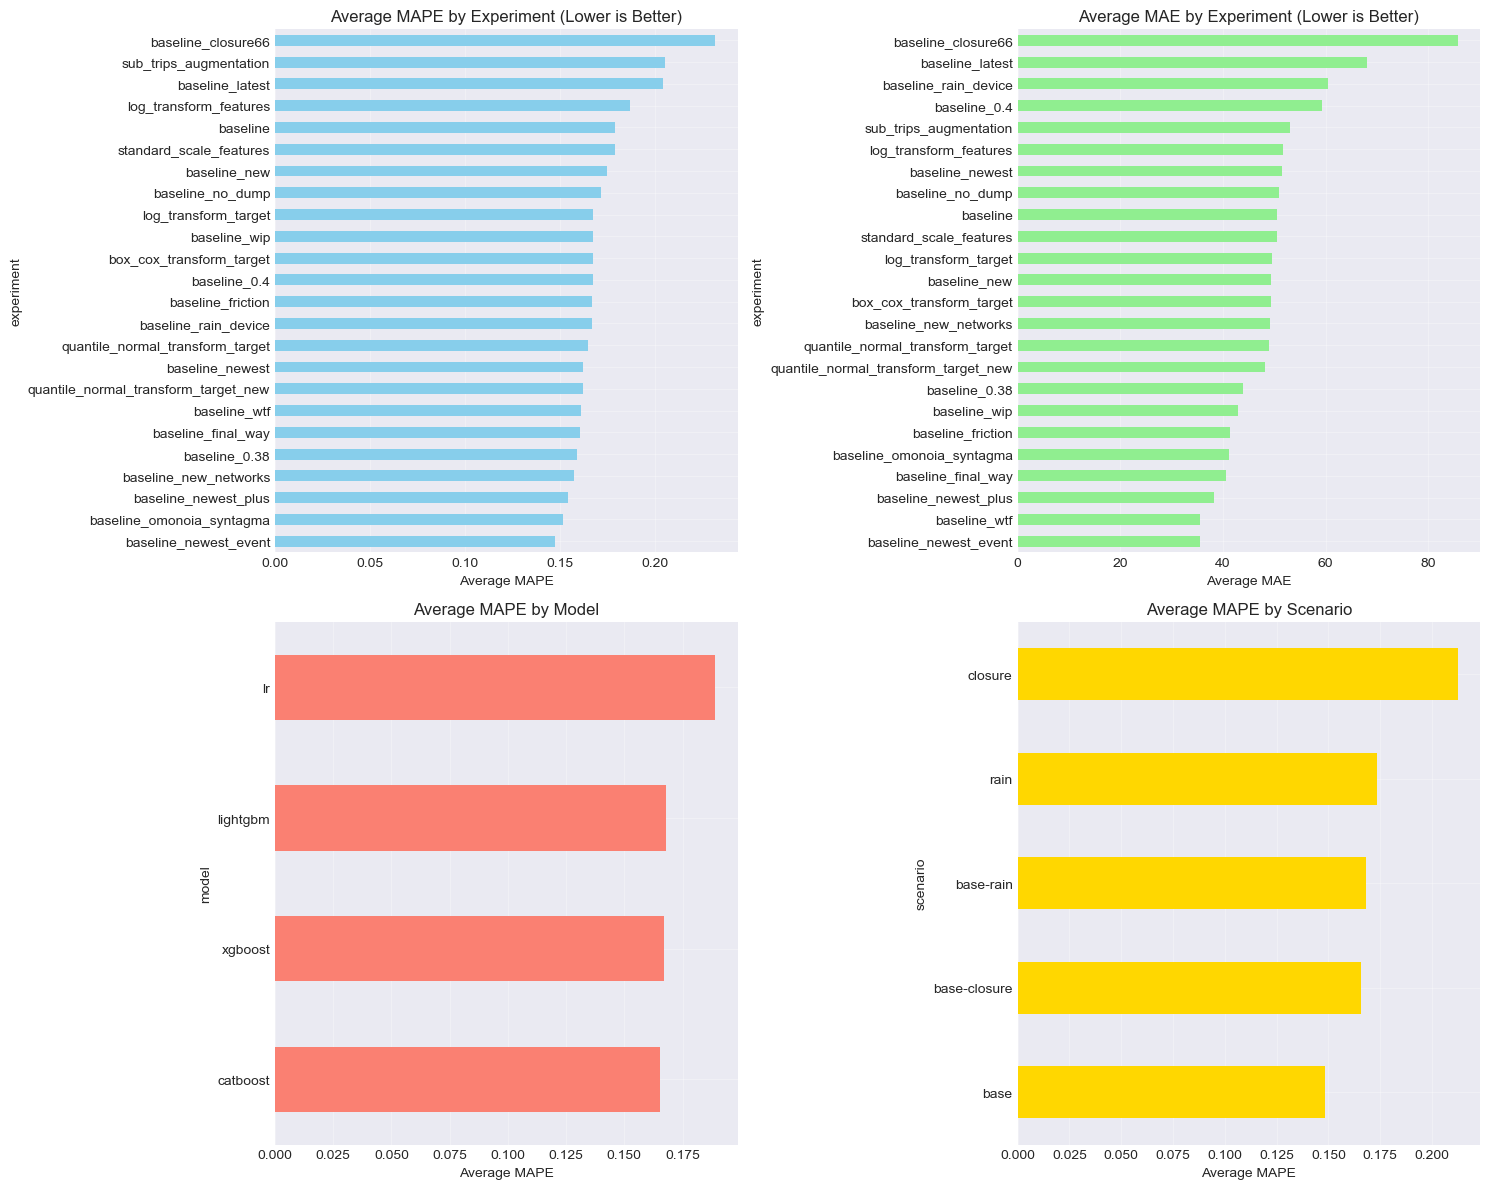

In [93]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. MAPE by Experiment
ax1 = axes[0, 0]
mape_by_exp = df_all.groupby("experiment")["mape"].mean().sort_values()
mape_by_exp.plot(kind="barh", ax=ax1, color="skyblue")
ax1.set_xlabel("Average MAPE")
ax1.set_title("Average MAPE by Experiment (Lower is Better)")
ax1.grid(True, alpha=0.3)

# 2. MAE by Experiment
ax2 = axes[0, 1]
mae_by_exp = df_all.groupby("experiment")["mae"].mean().sort_values()
mae_by_exp.plot(kind="barh", ax=ax2, color="lightgreen")
ax2.set_xlabel("Average MAE")
ax2.set_title("Average MAE by Experiment (Lower is Better)")
ax2.grid(True, alpha=0.3)

# 3. MAPE by Model
ax3 = axes[1, 0]
mape_by_model = df_all.groupby("model")["mape"].mean().sort_values()
mape_by_model.plot(kind="barh", ax=ax3, color="salmon")
ax3.set_xlabel("Average MAPE")
ax3.set_title("Average MAPE by Model")
ax3.grid(True, alpha=0.3)

# 4. MAPE by Scenario
ax4 = axes[1, 1]
mape_by_scenario = df_all.groupby("scenario")["mape"].mean().sort_values()
mape_by_scenario.plot(kind="barh", ax=ax4, color="gold")
ax4.set_xlabel("Average MAPE")
ax4.set_title("Average MAPE by Scenario")
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


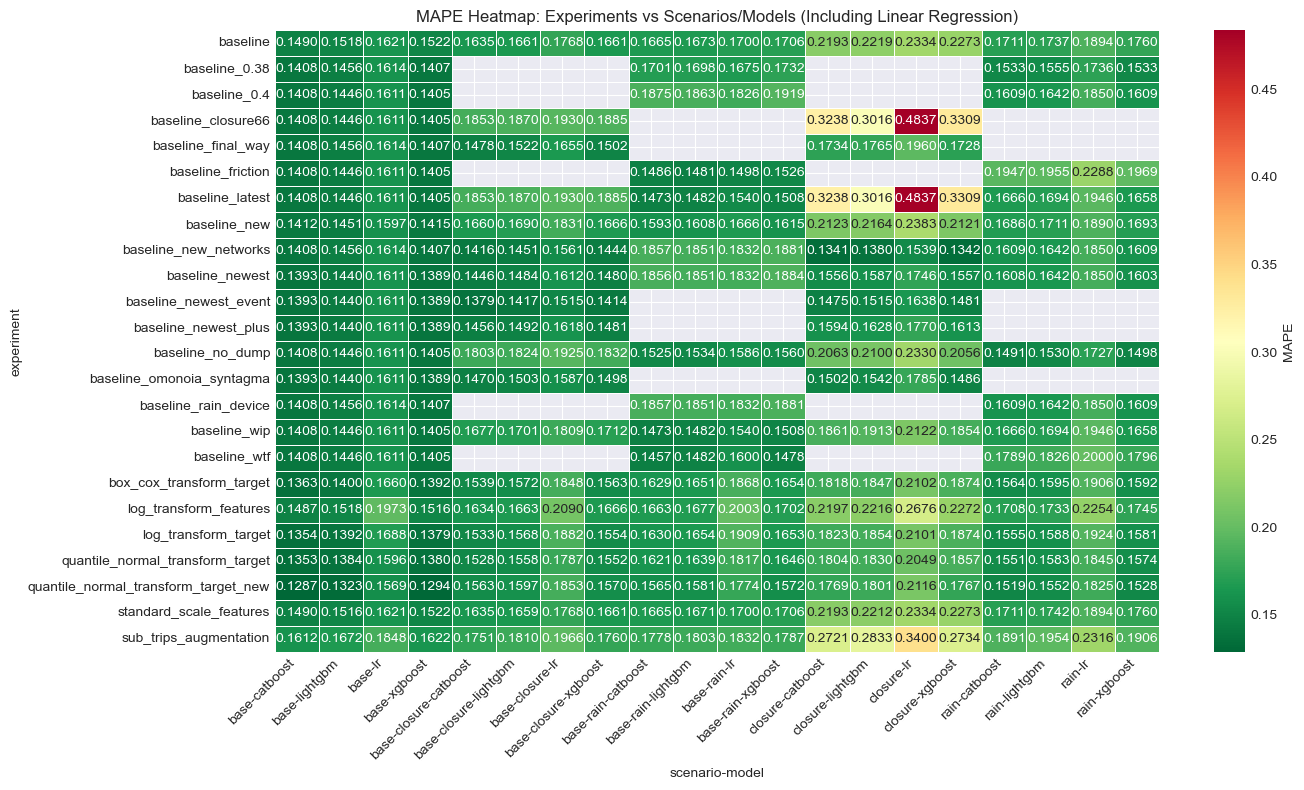

In [94]:
# Create a heatmap of MAPE values
plt.figure(figsize=(14, 8))

# Pivot the data for heatmap
pivot_data = df_all.pivot_table(values="mape", index="experiment", columns=["scenario", "model"], aggfunc="mean")

# Create heatmap
sns.heatmap(pivot_data, annot=True, fmt=".4f", cmap="RdYlGn_r", cbar_kws={"label": "MAPE"}, linewidths=0.5)
plt.title("MAPE Heatmap: Experiments vs Scenarios/Models (Including Linear Regression)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


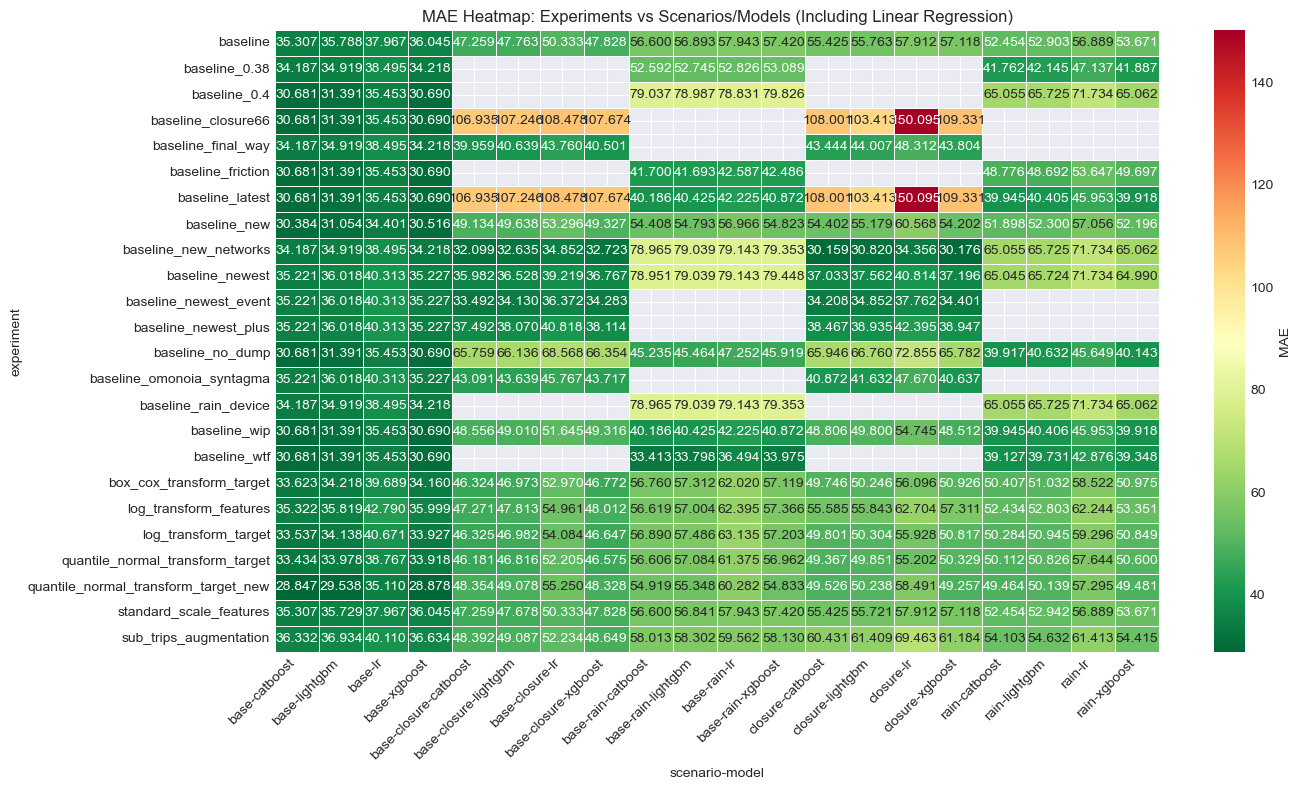

In [95]:
# Create a heatmap of MAE values
plt.figure(figsize=(14, 8))

# Pivot the data for heatmap
pivot_data = df_all.pivot_table(values="mae", index="experiment", columns=["scenario", "model"], aggfunc="mean")

# Create heatmap
sns.heatmap(pivot_data, annot=True, fmt=".3f", cmap="RdYlGn_r", cbar_kws={"label": "MAE"}, linewidths=0.5)
plt.title("MAE Heatmap: Experiments vs Scenarios/Models (Including Linear Regression)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Summary and Insights


In [96]:
# Find the best experiment overall (excluding baseline)
best_experiments = df_all[df_all["experiment"] != "baseline"].groupby("experiment")[["mape", "mae"]].mean()
best_experiment = best_experiments["mape"].idxmin()
best_mape = best_experiments.loc[best_experiment, "mape"]
best_mae = best_experiments.loc[best_experiment, "mae"]

# Calculate baseline averages
baseline_avg = df_all[df_all["experiment"] == "baseline"][["mape", "mae"]].mean()

print("SUMMARY OF EXPERIMENTS")
print("=" * 80)
print(f"\nBest Performing Experiment: {best_experiment}")
print(f"  - Average MAPE: {best_mape:.4f} (Baseline: {baseline_avg['mape']:.4f})")
print(f"  - Average MAE: {best_mae:.4f} (Baseline: {baseline_avg['mae']:.4f})")
print(f"  - MAPE Improvement: {((baseline_avg['mape'] - best_mape) / baseline_avg['mape'] * 100):.2f}%")
print(f"  - MAE Improvement: {((baseline_avg['mae'] - best_mae) / baseline_avg['mae'] * 100):.2f}%")

# Best model overall
best_model_avg = df_all.groupby("model")[["mape", "mae"]].mean()
best_model = best_model_avg["mape"].idxmin()
print(f"\nBest Performing Model Overall: {best_model}")
print(f"  - Average MAPE: {best_model_avg.loc[best_model, 'mape']:.4f}")
print(f"  - Average MAE: {best_model_avg.loc[best_model, 'mae']:.4f}")

# Scenario difficulty ranking
print("\nScenario Difficulty (by average MAPE):")
for scenario in avg_by_scenario.index:
    print(
        f"  - {scenario}: MAPE = {avg_by_scenario.loc[scenario, 'mape']:.4f}, MAE = {avg_by_scenario.loc[scenario, 'mae']:.4f}"
    )

# Top 5 best combinations
print("\nTop 5 Best Performing Combinations:")
for idx, row in df_ranking.head(5).iterrows():
    print(
        f"  {int(row['rank_by_mape'])}. {row['experiment']} + {row['model']} + {row['scenario']}: MAPE = {row['mape']:.4f}, MAE = {row['mae']:.4f}"
    )


SUMMARY OF EXPERIMENTS

Best Performing Experiment: baseline_newest_event
  - Average MAPE: 0.1472 (Baseline: 0.1787)
  - Average MAE: 35.5233 (Baseline: 50.4641)
  - MAPE Improvement: 17.62%
  - MAE Improvement: 29.61%

Best Performing Model Overall: catboost
  - Average MAPE: 0.1652
  - Average MAE: 48.5588

Scenario Difficulty (by average MAPE):
  - base: MAPE = 0.1481, MAE = 34.5290
  - base-closure: MAPE = 0.1657, MAE = 52.6923
  - base-rain: MAPE = 0.1682, MAE = 57.4516
  - rain: MAPE = 0.1736, MAE = 53.0581
  - closure: MAPE = 0.2125, MAE = 56.9756

Top 5 Best Performing Combinations:
  1. quantile_normal_transform_target_new + catboost + base: MAPE = 0.1287, MAE = 28.8471
  2. quantile_normal_transform_target_new + xgboost + base: MAPE = 0.1294, MAE = 28.8776
  3. quantile_normal_transform_target_new + lightgbm + base: MAPE = 0.1323, MAE = 29.5376
  4. baseline_new_networks + catboost + closure: MAPE = 0.1341, MAE = 30.1591
  5. baseline_new_networks + xgboost + closure: MAPE =

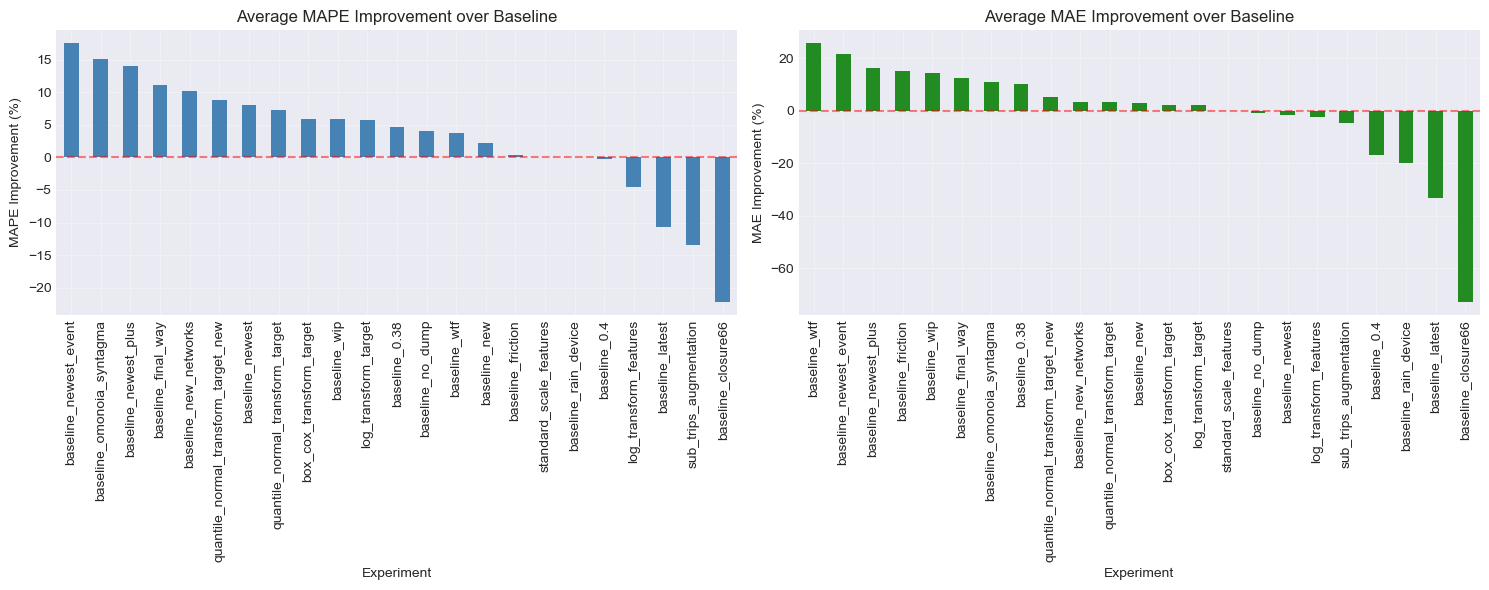

In [97]:
# Create improvement visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Calculate average improvements for each experiment
improvements = (
    df_all[df_all["experiment"] != "baseline"].groupby("experiment")[["mape_improvement", "mae_improvement"]].mean()
)

# MAPE Improvement
improvements["mape_improvement"].sort_values(ascending=False).plot(kind="bar", ax=ax1, color="steelblue")
ax1.set_ylabel("MAPE Improvement (%)")
ax1.set_title("Average MAPE Improvement over Baseline")
ax1.axhline(y=0, color="red", linestyle="--", alpha=0.5)
ax1.grid(True, alpha=0.3)
ax1.set_xlabel("Experiment")

# MAE Improvement
improvements["mae_improvement"].sort_values(ascending=False).plot(kind="bar", ax=ax2, color="forestgreen")
ax2.set_ylabel("MAE Improvement (%)")
ax2.set_title("Average MAE Improvement over Baseline")
ax2.axhline(y=0, color="red", linestyle="--", alpha=0.5)
ax2.grid(True, alpha=0.3)
ax2.set_xlabel("Experiment")

plt.tight_layout()
plt.show()